# 01 · Análisis Exploratorio de Datos (EDA)

**Objetivo:** entender qué hay en el dataset antes de tocar nada.
Este notebook es solo de **lectura y visualización** — no modifica ni guarda ningún archivo.

Dataset: listados de Airbnb obtenidos por web scraping.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8')
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
RAW_CSV = ROOT / 'data' / 'raw' / 'airbnb-listings-extract.csv'

print('Librerías cargadas.')

Librerías cargadas.


## 1 · Carga del dataset

In [2]:
house_data = pd.read_csv(RAW_CSV, sep=None, engine='python', on_bad_lines='warn')
print(f'Filas: {house_data.shape[0]:,}  |  Columnas: {house_data.shape[1]}')

Filas: 14,780  |  Columnas: 89


In [3]:
house_data.head()

,ID,Listing Url,Scrape ID,Last Scraped,Name,Summary,Space,Description,Experiences Offered,Neighborhood Overview,...,Review Scores Communication,Review Scores Location,Review Scores Value,License,Jurisdiction Names,Cancellation Policy,Calculated host listings count,Reviews per Month,Geolocation,Features
0,11210388,https://www.airbnb.com/rooms/11210388,20170306202425,2017-03-07,The Loft-Full Bath-Deck w/View,Loft in the Hill country 12-15 minutes directl...,This loft has a spectacular view of the hills ...,Loft in the Hill country 12-15 minutes directl...,none,This neighborhood is located in the hills west...,...,10.0,10.0,10.0,NaN,NaN,moderate,1.0,3.50,"30.3373609355,-97.8632766782","Host Is Superhost,Host Has Profile Pic,Host Id..."
1,17471131,https://www.airbnb.com/rooms/17471131,20170407214050,2017-04-08,"Claris I, Friendly Rentals","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...",none,Plaza Cataluña Catalonia Square is the large...,...,10.0,8.0,10.0,HUTB-006721,NaN,super_strict_30,106.0,0.86,"41.3896829422,2.17262543017","Host Has Profile Pic,Requires License,Instant ..."
2,17584891,https://www.airbnb.com/rooms/17584891,20170407214050,2017-04-08,"Style Terrace Red, Friendly Rentals","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...",none,Plaza Cataluña Catalonia Square is the large...,...,NaN,NaN,NaN,HUTB-007527,NaN,super_strict_30,106.0,NaN,"41.3930345489,2.16217327868","Host Has Profile Pic,Requires License,Instant ..."
3,5398030,https://www.airbnb.com/rooms/5398030,20170407214050,2017-04-08,Picasso Suite 1.4 Paseo de Gracia,Live like a local in Barcelona's most chic dis...,You wake up to the sun rising over Barcelona's...,Live like a local in Barcelona's most chic dis...,none,We're right in the heart of the chic L'Eixampl...,...,10.0,10.0,9.0,NaN,NaN,strict,24.0,1.09,"41.3969668101,2.1674178103","Host Has Profile Pic,Host Identity Verified,Re..."
4,18104606,https://www.airbnb.com/rooms/18104606,20170407214050,2017-04-08,Smart City Centre Apartment II,"Unique apartment in vibrant neighborhoods, car...","License: HUTB-005313 Charming apartment, locat...","Unique apartment in vibrant neighborhoods, car...",none,NaN,...,NaN,NaN,NaN,NaN,NaN,flexible,92.0,NaN,"41.3886851936,2.15514963616","Host Has Profile Pic,Host Identity Verified,Is..."


In [4]:
house_data.tail()

,ID,Listing Url,Scrape ID,Last Scraped,Name,Summary,Space,Description,Experiences Offered,Neighborhood Overview,...,Review Scores Communication,Review Scores Location,Review Scores Value,License,Jurisdiction Names,Cancellation Policy,Calculated host listings count,Reviews per Month,Geolocation,Features
14775,2098030,https://www.airbnb.com/rooms/2098030,20170502132028,2017-05-02,Spring into Bed Stuy!,"Sometimes I rent as a host (I'm here, guest st...","Simple, clean, modern one-bedroom in beautiful...","Sometimes I rent as a host (I'm here, guest st...",none,"There are plenty of restaurants, bars and othe...",...,10.0,9.0,10.0,NaN,NaN,strict,1.0,0.74,"40.67894535,-73.9393421856","Host Is Superhost,Host Has Profile Pic,Host Id..."
14776,17989442,https://www.airbnb.com/rooms/17989442,20170404145355,2017-04-06,"Paris 15 - Chambre cosy , near Eiffel tower",Paris- 15 -Résidence privée(code & gardien). Q...,"J'ai vécu au Canada, à Londres ,Madrid J'ai v...",Paris- 15 -Résidence privée(code & gardien). Q...,none,Quartier agréable par son côté résidentiel et ...,...,NaN,NaN,NaN,NaN,Paris,flexible,1.0,NaN,"48.8361969404,2.29404476423","Host Has Profile Pic,Is Location Exact,Instant..."
14777,13278634,https://www.airbnb.com/rooms/13278634,20170404145355,2017-04-05,Cozy Appartment Paris Batignolles,Cozy 2 bedroom apartment in core of Batignoles...,Very functional apartment in one of the most c...,Very functional apartment in one of the most c...,none,One of the most beautiful neighborhoods in Par...,...,10.0,10.0,10.0,NaN,NaN,strict,1.0,2.63,"48.8888092157,2.31617315267","Host Is Superhost,Host Has Profile Pic,Host Id..."
14778,10733941,https://www.airbnb.com/rooms/10733941,20160516142622,2016-05-18,City Park West Victorian Flat,"The space is in an older Victorian home, with ...",NaN,"The space is in an older Victorian home, with ...",none,NaN,...,10.0,10.0,10.0,NaN,NaN,moderate,1.0,0.94,"39.7422046438,-104.959933049","Host Has Profile Pic,Host Identity Verified,Is..."
14779,4637801,https://www.airbnb.com/rooms/4637801,20160104002432,2016-01-04,Sunny room near UW + buses downtown,Private room (SUNROOM IS USED FOR STORAGE AT T...,This is a 1920's house I bought recently and i...,Private room (SUNROOM IS USED FOR STORAGE AT T...,none,This is a residential neighborhood of Seattle ...,...,10.0,10.0,9.0,NaN,WASHINGTON,flexible,1.0,1.59,"47.6723272189,-122.291451162","Host Has Profile Pic,Host Identity Verified,Is..."


## 2 · Resumen estadístico

In [5]:
house_data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,14780.0,NaN,NaN,NaN,10280894.753518,5564828.94908,18628.0,5554731.5,11334923.0,15326313.5,19109692.0
Listing Url,14780,14780,https://www.airbnb.com/rooms/4637801,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Scrape ID,14780.0,NaN,NaN,NaN,20170373091036.304688,566797091.445724,20160104002432.0,20170407214119.0,20170407214119.0,20170407214119.0,20170615002708.0
Last Scraped,14780,37,2017-04-08,13627,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,14779,14375,Apartamento en el centro de Madrid,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
Cancellation Policy,14780,8,strict,5742,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Calculated host listings count,14776.0,NaN,NaN,NaN,9.486871,23.626014,1.0,1.0,2.0,5.0,145.0
Reviews per Month,11618.0,NaN,NaN,NaN,1.870014,1.86755,0.02,0.45,1.2,2.78,17.21
Geolocation,14780,14780,"47.6723272189,-122.291451162",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Tipos de datos y valores nulos por columna
house_data.info()
print('\nValores nulos por columna (top 20):')
print(house_data.isna().sum().sort_values(ascending=False).head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14780 entries, 0 to 14779
Data columns (total 89 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              14780 non-null  int64  
 1   Listing Url                     14780 non-null  object 
 2   Scrape ID                       14780 non-null  int64  
 3   Last Scraped                    14780 non-null  object 
 4   Name                            14779 non-null  object 
 5   Summary                         14189 non-null  object 
 6   Space                           10888 non-null  object 
 7   Description                     14774 non-null  object 
 8   Experiences Offered             14780 non-null  object 
 9   Neighborhood Overview           9134 non-null   object 
 10  Notes                           5644 non-null   object 
 11  Transit                         9066 non-null   object 
 12  Access                          

## 3 · Análisis de outliers en el precio

Usamos el método IQR (rango intercuartílico): se considera outlier cualquier valor
que esté muy por encima o muy por debajo del rango central del 50 % de los datos.

In [7]:
Q1 = house_data['Price'].quantile(0.25)
Q3 = house_data['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = house_data[
    (house_data['Price'] < lower_fence) | (house_data['Price'] > upper_fence)
]

total_validos = house_data['Price'].notna().sum()
pct_outliers = len(outliers) / total_validos * 100

print(f'Valla inferior: {lower_fence:.2f} €')
print(f'Valla superior: {upper_fence:.2f} €')
print(f'Outliers detectados: {len(outliers):,} ({pct_outliers:.2f} %)')
print()
print('Dado que representan más del 7 % de los datos, no los eliminamos.')
print('Son precios reales de alojamientos en el extremo alto/bajo del mercado.')

Valla inferior: -44.00 €
Valla superior: 164.00 €
Outliers detectados: 952 (6.45 %)

Dado que representan más del 7 % de los datos, no los eliminamos.
Son precios reales de alojamientos en el extremo alto/bajo del mercado.


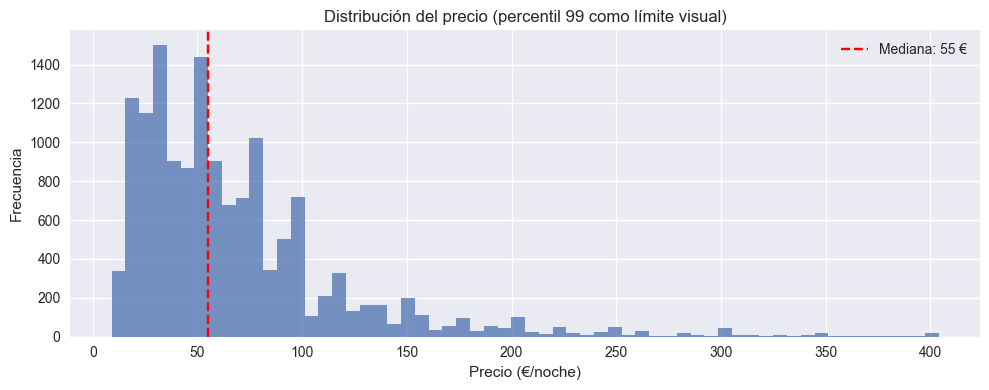

In [8]:
# Distribución del precio (sin outliers extremos para visualizar mejor)
precio_recortado = house_data['Price'].dropna()
precio_recortado = precio_recortado[precio_recortado < precio_recortado.quantile(0.99)]

plt.figure(figsize=(10, 4))
plt.hist(precio_recortado, bins=60, alpha=0.75)
plt.axvline(precio_recortado.median(), color='red', linestyle='--', label=f'Mediana: {precio_recortado.median():.0f} €')
plt.xlabel('Precio (€/noche)')
plt.ylabel('Frecuencia')
plt.title('Distribución del precio (percentil 99 como límite visual)')
plt.legend()
plt.tight_layout()
plt.show()

## 4 · Análisis solo para Madrid

El dataset incluye varias ciudades. Filtramos Madrid para el análisis de correlaciones,
ya que es el subconjunto que usaremos para modelar.

In [9]:
# Limpieza mínima para exploración
cols_to_drop = [
    'ID', 'Listing Url', 'Scrape ID', 'Last Scraped', 'Name', 'Summary', 'Space', 'Description',
    'Experiences Offered', 'Neighborhood Overview', 'Notes', 'Transit', 'Access', 'Interaction',
    'House Rules', 'Thumbnail Url', 'Medium Url', 'Picture Url', 'XL Picture Url', 'Host ID',
    'Host URL', 'Host Name', 'Host Since', 'Host Location', 'Host About', 'Host Response Time',
    'Host Response Rate', 'Host Acceptance Rate', 'Host Thumbnail Url', 'Host Picture Url',
    'Host Neighbourhood', 'Host Listings Count', 'Street', 'Smart Location', 'Country Code',
    'Calendar Updated', 'Has Availability', 'Calendar last Scraped', 'First Review', 'Last Review',
    'License', 'Jurisdiction Names', 'Calculated host listings count', 'Reviews per Month', 'Features',
    'Geolocation', 'Latitude', 'Longitude', 'Country', 'Host Verifications', 'Amenities',
    'Weekly Price', 'Monthly Price', 'Extra People', 'Neighbourhood', 'zipcode'
]

df_clean = house_data.drop(columns=[c for c in cols_to_drop if c in house_data.columns])
df_clean['Square Meters'] = df_clean['Square Feet'] * 0.092903
df_clean = df_clean.drop('Square Feet', axis=1)

madrid = df_clean[df_clean['City'] == 'Madrid'].copy()
madrid = madrid.dropna(subset=['Price'])

print(f'Anuncios en Madrid: {madrid.shape[0]:,}')
print(f'Porcentaje del total: {madrid.shape[0] / house_data.shape[0] * 100:.2f} %')

Anuncios en Madrid: 13,198
Porcentaje del total: 89.30 %


## 5 · Correlaciones con el precio

In [10]:
num_cols = madrid.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = madrid[num_cols].corr()

# Correlaciones ordenadas con Price
print('Correlación de cada variable con el precio:')
print(corr_matrix['Price'].sort_values(ascending=False).to_string())

Correlación de cada variable con el precio:
Price                          1.000000
Cleaning Fee                   0.657318
Accommodates                   0.580916
Bedrooms                       0.525673
Beds                           0.486250
Guests Included                0.371806
Security Deposit               0.362665
Bathrooms                      0.349508
Square Meters                  0.309067
Host Total Listings Count      0.188948
Review Scores Location         0.146181
Review Scores Cleanliness      0.084334
Availability 365               0.077236
Review Scores Accuracy         0.056243
Review Scores Rating           0.055743
Minimum Nights                 0.030708
Review Scores Value            0.019117
Availability 30                0.018257
Availability 60                0.004681
Maximum Nights                 0.003059
Review Scores Communication   -0.000315
Availability 90               -0.011550
Review Scores Checkin         -0.012520
Number of Reviews             -0.033

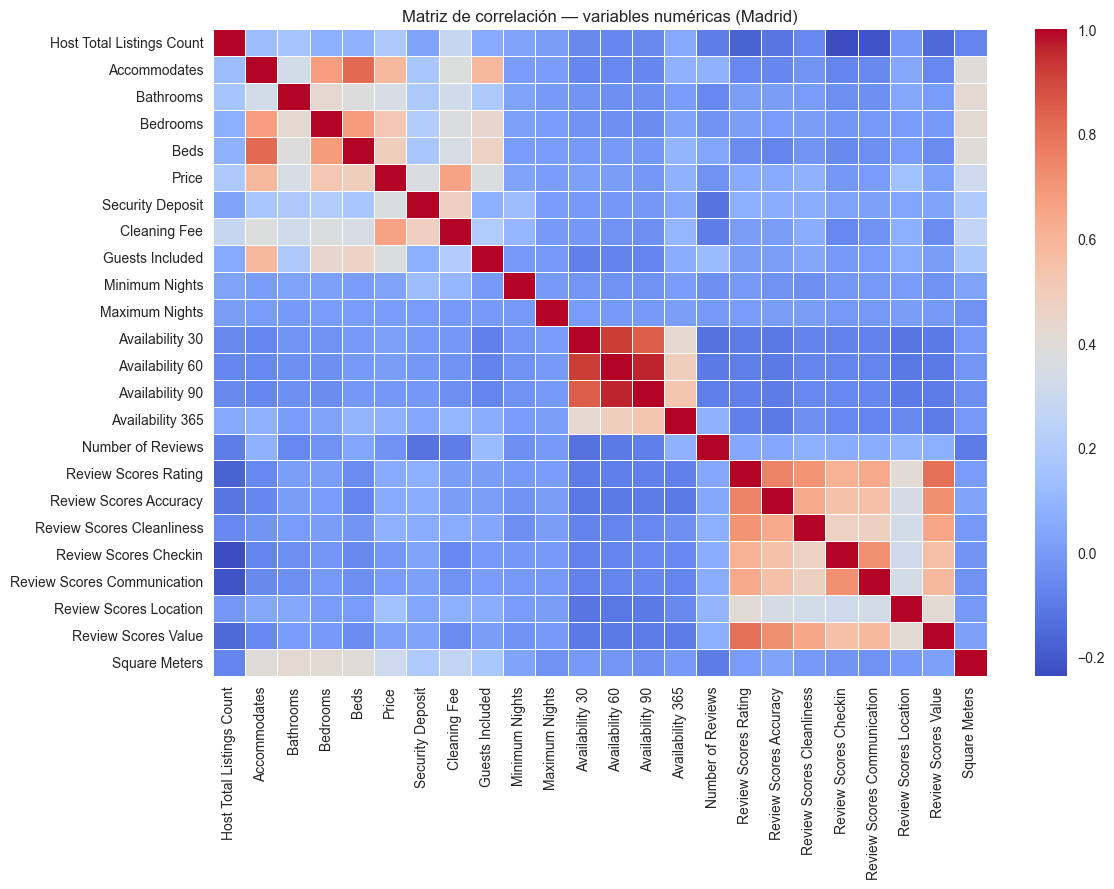

In [11]:
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Matriz de correlación — variables numéricas (Madrid)')
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'figures' / 'correlation_matrix.png', dpi=120)
plt.show()

## 6 · Informe automático con ydata-profiling

Genera un informe HTML completo con estadísticas, distribuciones, correlaciones y alertas.
Los informes ya están guardados en `reports/profiling/`. Descomenta para regenerarlos.

In [12]:
# from ydata_profiling import ProfileReport
#
# profile_madrid = ProfileReport(madrid, title='Profiling Report — Madrid')
# profile_madrid.to_file(ROOT / 'reports' / 'profiling' / 'profiling_report_madrid.html')
# profile_madrid.to_notebook_iframe()

print('Informes disponibles en reports/profiling/')

Informes disponibles en reports/profiling/
